<a href="https://colab.research.google.com/github/AqsaHerryPrastyo/PCVK/blob/main/WEEK_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

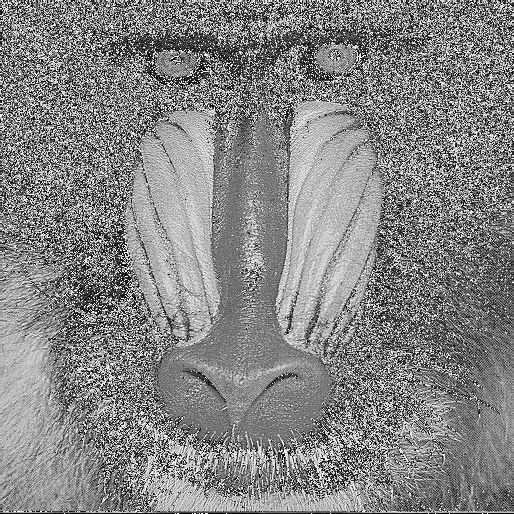

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

def convulation2d(image, kernel, stride, padding):
  """
  Performs 2D convolution on an image.

  Args:
    image: The input image (grayscale).
    kernel: The convolution kernel.
    stride: The stride for the convolution.
    padding: The padding to apply to the image.

  Returns:
    The convoluted image.
  """
  image_padded = cv.copyMakeBorder(image, padding, padding, padding, padding, cv.BORDER_REPLICATE)
  image_height, image_width = image_padded.shape
  kernel_height, kernel_width = kernel.shape

  output_height = int(((image_height - kernel_height) / stride) + 1)
  output_width = int(((image_width - kernel_width) / stride) + 1)

  output_image = np.zeros((output_height, output_width), dtype=np.float32)

  for y in range(0, image_height - kernel_height + 1, stride):
    for x in range(0, image_width - kernel_width + 1, stride):
      output_image[y // stride, x // stride] = np.sum(image_padded[y:y + kernel_height, x:x + kernel_width] * kernel)

  return output_image.astype(np.uint8)

img = cv.imread('/content/drive/MyDrive/Image/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

kernel_sharpen = np.array([[0,-1,0],
                          [-1,5,-1],
                          [0,-1,0]])

output_img = convulation2d(img_gray, kernel_sharpen, 1, 2)
cv2_imshow(output_img)

## Percobaan 1:
Pada percobaan 1 ini, kita akan membuat Filter Gaussian, Sharpen, dan Canny menggunakan library
filter2d dari OpenCV. Filter ini akan kita terapkan pada Image RGB. Pada bagian awal kode terdapat
fungsi show_side_by_side yang digunakan untuk menampilkan gambar secara berdampingan.

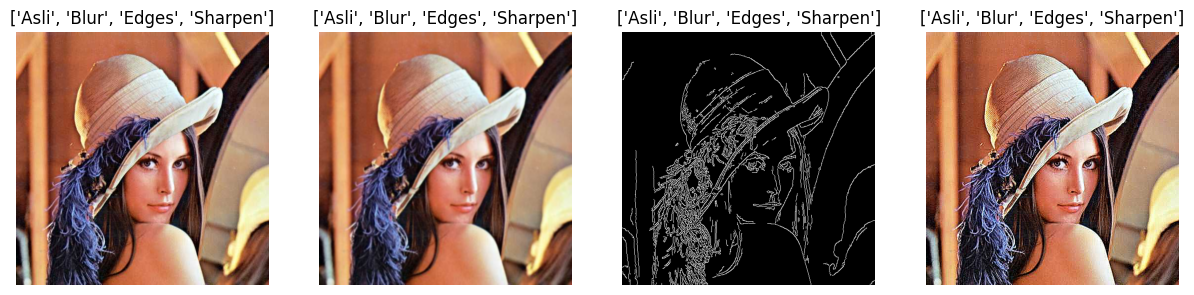

In [5]:
def show_side_by_side(images, titles, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (img,title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)
        if len(img.shape) == 2:
            plt.imshow(img, cmap='gray')
        else:
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(titles)
        plt.axis('off')
    plt.show()

img = cv.imread('/content/drive/MyDrive/Image/lena.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

blur = cv.GaussianBlur(img,(7,7),1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY),100,200)
sharpen_kernel = np.array([[0,-1,0],
                           [-1,5,-1],
                           [0,-1,0]])
sharpen = cv.filter2D(img, -1, sharpen_kernel)

show_side_by_side([img, blur, edges, sharpen], ['Asli', 'Blur', 'Edges', 'Sharpen'])

##Percobaan 2:
Pada percobaan 2 berikut ini akan dilakukan filtering modern dari Library OpenCV. Dua filter yang akan
digunakan adalah Bilateral Filtering dan Guided Filter.

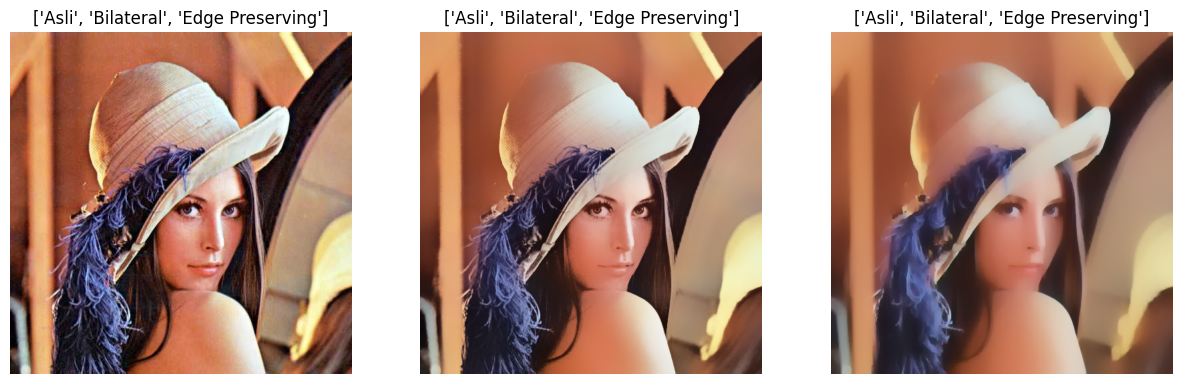

In [6]:
import cv2 as cv
import numpy as np # Tambahkan import numpy juga jika diperlukan di sel ini

# Pindahkan baris pembacaan dan konversi gambar ke awal sel
img = cv.imread('/content/drive/MyDrive/Image/lena.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

bilateral = cv.bilateralFilter(img, 50, 100, 100)
edges_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)


# Menggunakan show_side_by_side jika sel nFeqSUWEE4Kl sudah dijalankan
show_side_by_side([img, bilateral, edges_preserve], ['Asli', 'Bilateral', 'Edge Preserving'])

## Percobaan 3:
Percobaan kali ini akan mencoba melihat proses Filtering pada CNN (bagian Feature Map), lakukan
running code beberapa kali dan perhatikan hasil outputnya. Apa yang dapat kamu simpulkan dari hasil
keluaran tersebut.

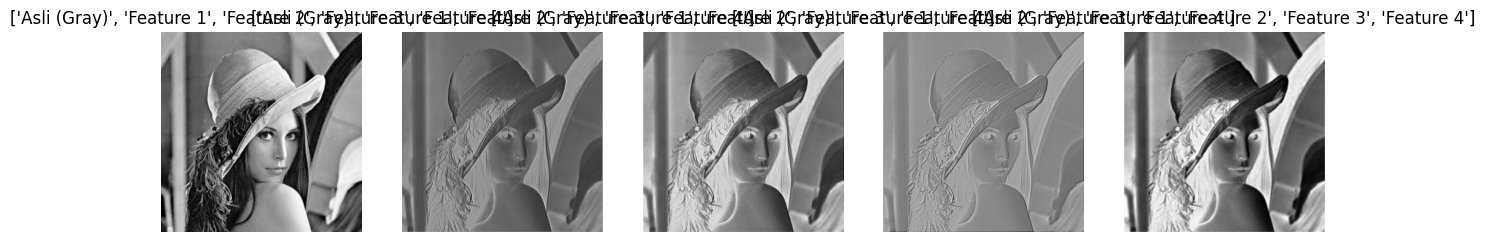

In [10]:
# Filter Feature Map yang digunakan pada CNN, Lakukan running code bagian ini beberapa kali dan perhatikan hasilnya
import torch
import torch.nn as nn
import cv2 as cv # Import cv2 library
import numpy as np # Import numpy library

# Ambil gambar dan konversi ke grayscale
img = cv.imread('/content/drive/MyDrive/Image/lena.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)


class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()

# Ubah gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Hasil CNN
with torch.no_grad():
    features = model(img_tensor)

# Visualisasi feature maps
feature_maps = [features[0,i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps, ["Asli (Gray)"] + [f"Feature {i+1}" for i in range(len(feature_maps))])


## Percobaan 4:
Percobaan kali ini akan melakukan efek Beauty dan Vintage yang biasanya digunakan pada Aplikasi
popular saat ini. Filter yang digunakan merupakan kombinasi dari filter tradisional. Perlu diketahui
untuk filter aplikasi popular bisa jadi tidak menggunakan metode yang sama. Pada Aplikasi popular
bisa jadi menggunakan model GenAI dengan data Training untuk memberikan hasil yang lebih akurat.

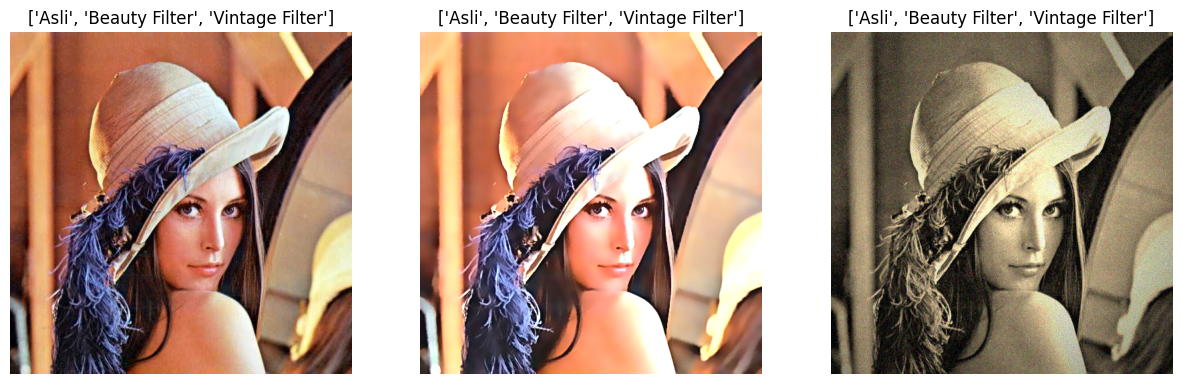

In [13]:
img = cv.imread('/content/drive/MyDrive/Image/lena.jpg')


# ========================
# 1. Beauty Filter
# ========================

# Step 1: Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# Step 2: Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0,0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

# Step 3: Brightness & contrast
alpha = 1.2  # contrast
beta = 15    # brightness
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)


# ========================
# 2. Old/Vintage Filter
# ========================

# Step 1: Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Step 2: Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:,:,i] = vignette[:,:,i] * mask

# Step 3: Noise/Grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int64) + noise, 0, 255).astype(np.uint8) # Fixed type casting

# Display the images side by side
show_side_by_side([img, beauty, old_img], ['Asli', 'Beauty Filter', 'Vintage Filter'])

## Percobaan 5
akan menunjukkan pada anda filter anime / cartoon menggunakan kombinasi filter
tradisional.

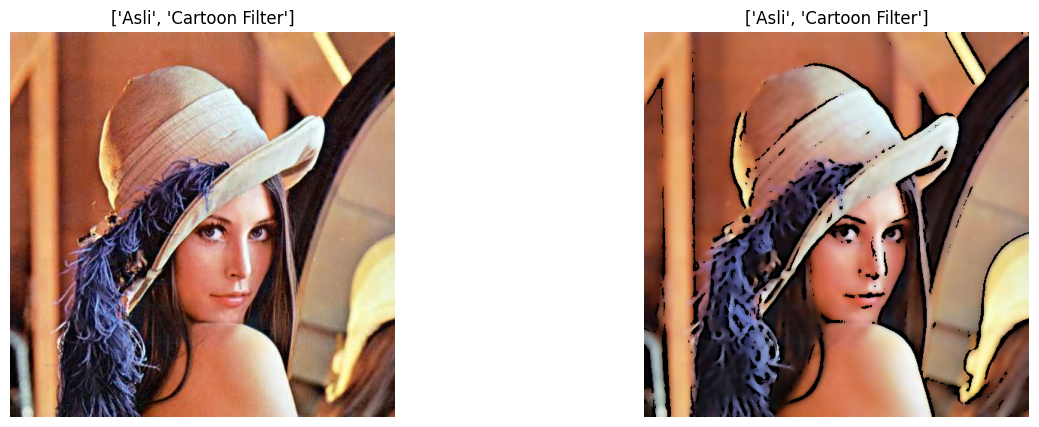

In [14]:
# Filter Anime / Cartoon
# Step 1: Edge detection (pakai median blur dulu agar gambar menjadi lebih halus)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                             cv.ADAPTIVE_THRESH_MEAN_C,
                             cv.THRESH_BINARY, 9, 9)

# Step 2: Bilateral filter untuk smoothing warna
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

# Step 3: Gabungkan (cartoonize)
cartoon = cv.bitwise_and(color, color, mask=edges)

# Tampilkan
show_side_by_side([img, cartoon], ["Asli", "Cartoon Filter"])

## Percobaan 6:
Pada Percobaan 6 akan ditunjukkan contoh Filter Malam.

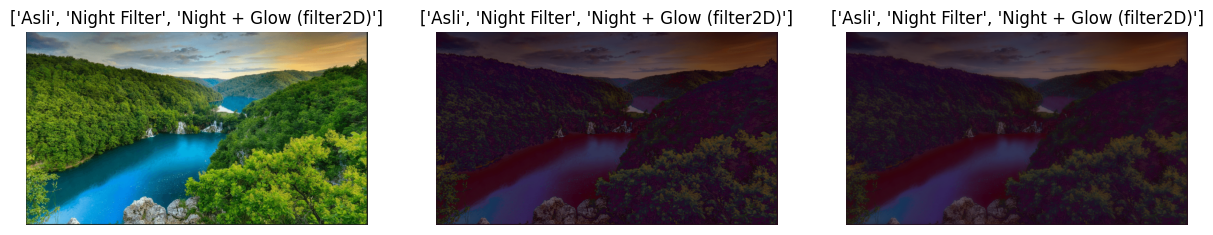

In [16]:
# Night Filter
img = cv.imread("/content/drive/MyDrive/Image/jungle.png") # Corrected image path
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Step 1: Gelapkan (contrast turun, brightness negatif)
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

# Step 2: Tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100)) # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15,15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

# Kombinasikan asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([img, night, night_glow],
                  ["Asli", "Night Filter", "Night + Glow (filter2D)"])

## Percobaan 7
Percobaan 7 menunjukkan Filter Pagi dan Pagi ditambahkan efek kabut.

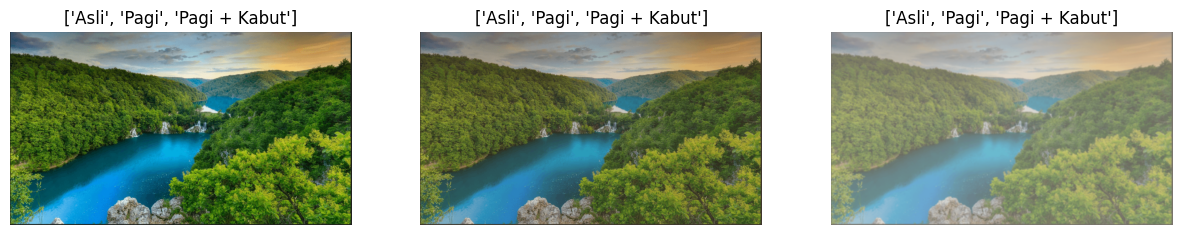

In [17]:
img = cv.imread("/content/drive/MyDrive/Image/jungle.png")

# Filter Suasana pagi dan Kabut
# ========================
# Step 1: Kurangi kontras & cerahkan
# ========================
alpha = 0.9  # contrast
beta = 20    # brightness
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

# ========================
# Step 2: Tambahkan warm tone (kemerahan / oranye)
# ========================
warm_tint = np.full_like(soft, (40, 70, 120)) # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# ========================
# Step 3: Tambahkan haze (kabut tipis) dengan filter2D
# ========================
# Kernel blur Gaussian-like untuk menciptakan efek kabut
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T # jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)

# tambah Layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([img, pagi, kabut],
                  ["Asli", "Pagi", "Pagi + Kabut"])